In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'torch'

In [ ]:
red = "\033[31;1m"
green = "\033[32;1m"
blue = "\033[34;1m"
purple = "\033[35;1m"

In [ ]:
torch.manual_seed(43)
np.random.seed(43)

In [ ]:
def generate_data(n_samples=1000):
    n_samples_per_class = n_samples // 2
    
    #Samples centered at 2, 2
    class0_x = 2 + 0.8 * np.random.randn(n_samples_per_class, 2)
    class0_y = np.zeros(n_samples_per_class)
    
    #Samples centered at 4, 4
    class1_x = 4 + 0.8 * np.random.randn(n_samples_per_class, 2)
    class1_y = np.ones(n_samples_per_class)
    
    x = np.vstack((class0_x, class1_x))
    y = np.concatenate((class0_y, class1_y))
    
    indices = np.random.permutation(n_samples)
    x, y = x[indices], y[indices]

    return x, y    

In [ ]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_sizes, dropout_prob=0.2) -> None:
        super(FeedForwardNN, self).__init__()
        
        layers = []
        
        layers.append(nn.Linear(input_size, hidden_sizes[0]))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_prob))
        
        for i in range (0, len(hidden_sizes)-1):
            layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_prob))
            
        layers.append(nn.Linear(hidden_sizes[-1], output_sizes))
        
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.model(x)
    
    

In [ ]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=100, early_stopping_patience=10, device="cpu"):
    model = model.to(device)
    
    train_losses = []
    valid_losses = []
    train_accuracies = []
    valid_accuracies = []
    
    best_valid_loss = float("inf")
    epochs_without_improvement = 0
    
    for epoch in range(0, epochs):
        model.train()
        
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            
            #Forward Pass
            outputs = model(inputs)
            
            #Binary Classification with one output neuron
            if outputs.shape[1] == 1:
                loss = criterion(outputs.squeeze(), targets.float())
                predictions = (torch.sigmoid(outputs) > 0.5).squeeze().long()
            else:
                loss = criterion(outputs, targets.long())
                _, predictions = torch.max(outputs, 1)
                
            #Backward Pass and optimize
            loss.backward()
            optimizer.step()
            
            #Update metrics
            train_loss += loss.item() * inputs.size(0)
            train_correct += (predictions == targets).sum().item()
            train_total += targets.size(0)
            
        #Calculating avg training metrics
        avg_train_loss = train_loss / len(train_loader.dataset)
        train_accuracy = train_correct / train_total
        
        #Validation
        model.eval()
        valid_loss = 0.0
        valid_correct = 0
        valid_total = 0
        
        with torch.no_grad():
            for inputs, targets in valid_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                
                #Binary Classification with one output neuron
                if outputs.shape[1] == 1:
                    loss = criterion(outputs.squeeze(), targets.float())
                    predictions = (torch.sigmoid(outputs) > 0.5).squeeze().long()
                else:
                    loss = criterion(outputs, targets.long())
                    _, predictions = torch.max(outputs, 1)
                
                valid_loss += loss.item() * inputs.size(0)
                valid_correct += (predictions == targets).sum().item()
                valid_total += targets.size(0)
        
        avg_valid_loss = valid_loss / len(valid_loader.dataset)
        valid_accuracy = valid_correct / valid_total
        
        train_losses.append(avg_train_loss)
        train_losses.append(avg_valid_loss)
        train_accuracies.append(train_accuracy)
        valid_accuracies.append(valid_accuracy)
        
        print(f"{blue}Epoch: {epoch+1}/{epochs}:")
        print(f"{purple}Train loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}")
        print(f"Valid loss: {avg_valid_loss:.4f}, Valid Acc: {valid_accuracy:.4f}")
        
        #Early stop check
        if avg_valid_loss < best_valid_loss:
            best_valid_loss = avg_valid_loss
            epochs_without_improvement = 0
            #Saving best model
            best_model = model.state_dict().copy()
        else:
            epochs_without_improvement += 1
            
        if epochs_without_improvement >= early_stopping_patience:
            print(f"{red}Early stopping after epochs {epoch+1} epochs")
            break

    #Load best model
    model.load_state_dict(best_model)

    metrics = {
        "train_losses": train_losses, 
        "valid_losses": valid_losses,
        "train_accuracies": train_accuracies,
        "valid_accuracies": valid_accuracies
    }

    return model, metrics

In [ ]:
def plot_metrics(metrics):
    plt.figure(figsize=(12, 8))
    
    #Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(metrics["train_losses"], label="Training Loss")
    plt.plot(metrics["valid_losses"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over time")
    plt.legend()
    
    #Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(metrics["train_accuracies"], label="Training Accuracy")
    plt.plot(metrics["valid_accuracies"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracies")
    plt.title("Accuracy over time")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
#Visualizing Decision Boundaries
def plot_decision_boundary(model, x, y, device="cpu"):
    #Defining the grid for visualization
    x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
    
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    )
    
    #Predicting class for each point in the grid
    model.eval()
    with torch.no_grad():
        grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)
        outputs = model(grid)
        
        #Binary Classification
        if outputs.shape[1] == 1:
            z = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
        else: #Multi-Level Classification
            _, z = torch.max(outputs, 1)
            z = z.cpu().numpy()
    
    #Reshape z to match grid shape
    z = z.reshape(xx.shape)

    #Plotting contour and training points
    plt.figure(figsize=(12, 8))
    plt.contourf(xx, yy, z, alpha=0.8)
    plt.scatter(x[:, 0], x[:, 1], c=y, edgecolors="k", marker="o", s=50)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundary")
    plt.colorbar()
    plt.show()

In [ ]:
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using Device:  {device}.")
    
    #generate data
    x, y = generate_data(n_samples=1000)
    print(f"Data Shape: x={x.shape}, y={y.shape}")
    
    #Converting data to pytorch tensors
    x_tensor = torch.tensor(x, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)
    
    #Split data into train and validation (80/20)
    train_size = int(0.8 * len(x_tensor))
    x_train, x_valid = x_tensor[:train_size], x_tensor[train_size:]
    y_train, y_valid = y_tensor[:train_size], y_tensor[train_size:]
    
    #Creating data loaders
    train_dataset = TensorDataset(x_train, y_train)
    valid_dataset = TensorDataset(x_valid, y_valid)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=32)
    
    input_size = x.shape[1]
    hidden_sizes = [64, 32]
    output_size = 1
    
    model = FeedForwardNN(input_size, hidden_sizes, output_size)
    print(model)
    
    #Defining loss function and optimizer
    criterion = nn.BCEWithLogitsLoss() #Binary cross-entropy with logits
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    #Training the model
    trained_model, metrics = train_model(
        model, train_loader, valid_loader, criterion, optimizer, epochs=100, early_stopping_patience=10, device=device
    )
    
    plot_metrics(metrics)
    plot_decision_boundary(trained_model, x, y, device)
    
    return trained_model

Using Device:  cpu.
Data Shape: x=(1000, 2), y=(1000,)
FeedForwardNN(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Epoch: 1/100:
Train loss: 0.4768, Train Acc: 0.7700
Valid loss: 0.2215, Valid Acc: 0.9550
Epoch: 2/100:
Train loss: 0.2471, Train Acc: 0.9125
Valid loss: 0.1252, Valid Acc: 0.9450
Epoch: 3/100:
Train loss: 0.2065, Train Acc: 0.9287
Valid loss: 0.1043, Valid Acc: 0.9650
Epoch: 4/100:
Train loss: 0.1769, Train Acc: 0.9275
Valid loss: 0.1129, Valid Acc: 0.9500
Epoch: 5/100:
Train loss: 0.1494, Train Acc: 0.9513
Valid loss: 0.0933, Valid Acc: 0.9700
Epoch: 6/100:
Train loss: 0.1523, Train Acc: 0.9425
Valid loss: 0.0966, Valid Acc: 0.9600
Epoch: 7/100:
Train loss: 0.1448, Train Acc: 0.9463
Valid loss: 0.0922, V

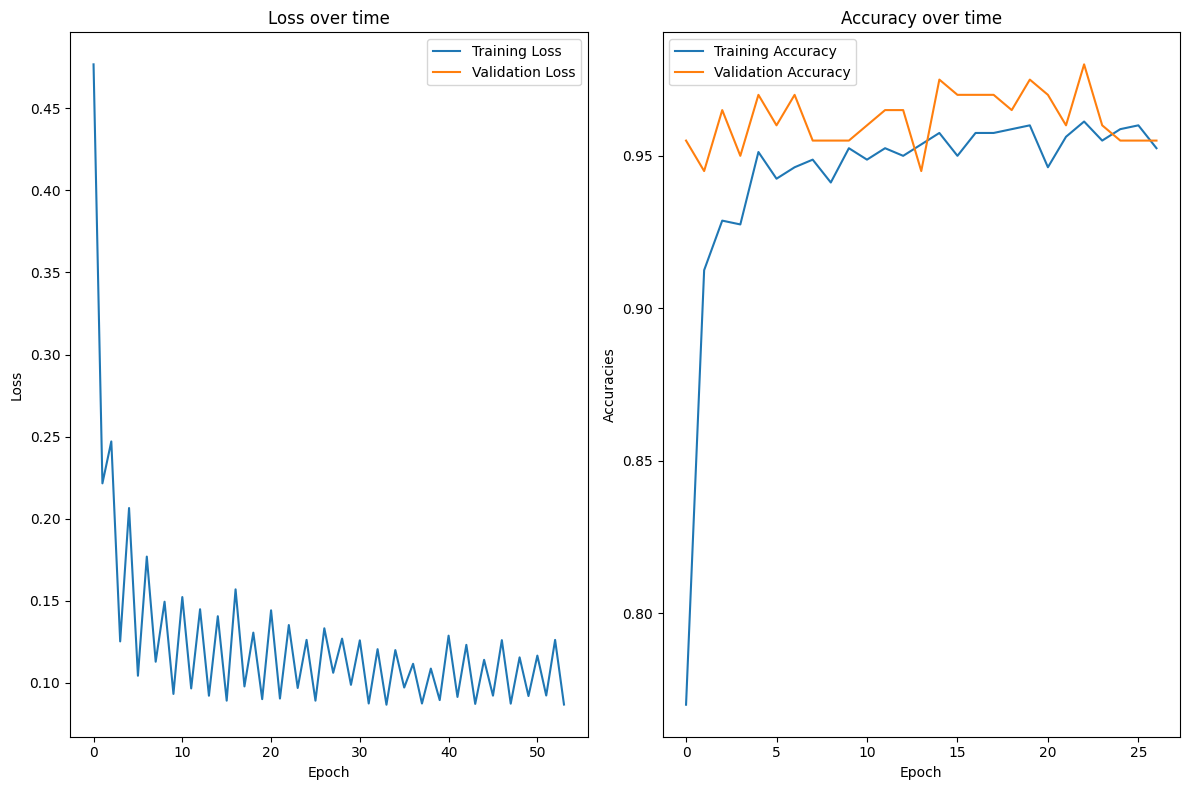

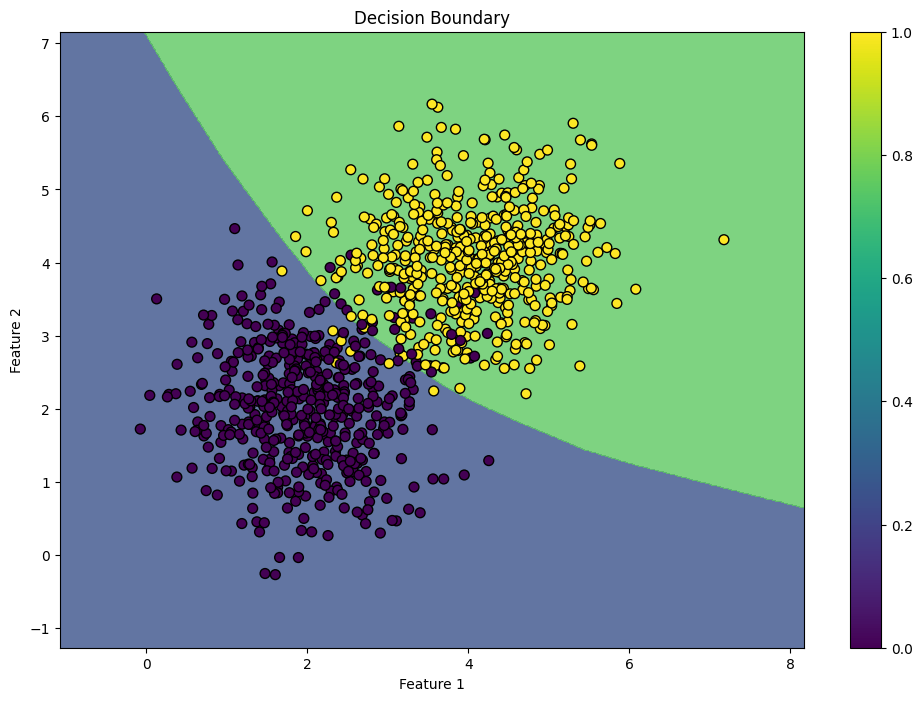

FeedForwardNN(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [ ]:
main()